In [3]:
import torch
from transformers import LlavaNextProcessor, LlavaNextForConditionalGeneration, BitsAndBytesConfig
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import json
import cv2

from segment_anything import sam_model_registry, SamPredictor


In [4]:
llava_model_id = "llava-hf/llava-v1.6-mistral-7b-hf"  # 7B LLaVA-Next
sam_checkpoint = "sam_vit_l_0b3195.pth"               # path to downloaded SAM ViT-L
sam_model_type = "vit_l"


In [5]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

processor = LlavaNextProcessor.from_pretrained(llava_model_id)

llava_model = LlavaNextForConditionalGeneration.from_pretrained(
    llava_model_id,
    quantization_config=quant_config,
    device_map="auto",
)
llava_model.eval()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 4/4 [00:27<00:00,  6.77s/it]


LlavaNextForConditionalGeneration(
  (model): LlavaNextModel(
    (vision_tower): CLIPVisionModel(
      (vision_model): CLIPVisionTransformer(
        (embeddings): CLIPVisionEmbeddings(
          (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
          (position_embedding): Embedding(577, 1024)
        )
        (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (encoder): CLIPEncoder(
          (layers): ModuleList(
            (0-23): 24 x CLIPEncoderLayer(
              (self_attn): CLIPAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
              )
              (layer_norm1): LayerNorm((1024,), eps=1e-05, elementw

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

sam = sam_model_registry[sam_model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
sam_predictor = SamPredictor(sam)


Using device: cuda


/home/ubuntu/additional_drive/shwan_data/auto_annotations/llavaenv/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

In [61]:
image_path = "../../../scripts/all_frames/Columbia_valley__848375002379__1/Columbia_valley__848375002379__1_frame_012.png"
image_pil = Image.open(image_path).convert("RGB")
image_np = np.array(image_pil)  # H x W x 3
h, w = image_np.shape[:2]
print(h, w)


1920 1080


In [62]:
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": (
                    "You are a product annotation assistant.\n"
                    "Look at ALL products in the image and return ONLY valid JSON. "
                    "Follow this exact structure:\n\n"
                    "{\n"
                    "  \"products\": [\n"
                    "    {\n"
                    "      \"category\": \"\",\n"
                    "      \"tags\": [],\n"
                    "      \"bbox\": [x_min, y_min, x_max, y_max]\n"
                    "    }\n"
                    "  ]\n"
                    "}\n\n"
                    "Rules:\n"
                    "- Detect EVERY product visible.\n"
                    "- products[] should contain 1 object per product.\n"
                    "- bbox MUST use normalized image coordinates (0 to 1).\n"
                    "- bbox must tightly enclose that individual product.\n"
                    "- Return ONLY the JSON, no explanation, no markdown, no ```json fences.\n"
                ),
            },
        ],
    }
]


prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)

inputs = processor(
    image_pil,
    prompt,
    return_tensors="pt"
).to(llava_model.device)

with torch.no_grad():
    output_ids = llava_model.generate(
        **inputs,
        max_new_tokens=256,
        do_sample=False,
        temperature=0.0,
    )

response_text = processor.decode(output_ids[0], skip_special_tokens=True)
print(response_text)


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST]  
You are a product annotation assistant.
Look at ALL products in the image and return ONLY valid JSON. Follow this exact structure:

{
  "products": [
    {
      "category": "",
      "tags": [],
      "bbox": [x_min, y_min, x_max, y_max]
    }
  ]
}

Rules:
- Detect EVERY product visible.
- products[] should contain 1 object per product.
- bbox MUST use normalized image coordinates (0 to 1).
- bbox must tightly enclose that individual product.
- Return ONLY the JSON, no explanation, no markdown, no ```json fences.
 [/INST] ```json
{
  "products": [
    {
      "category": "Wine",
      "tags": ["Trevé", "Bruce", "Sparkling"],
      "bbox": [0.000,0.000,0.498,0.986]
    },
    {
      "category": "Wine",
      "tags": ["Trevé", "Bruce", "Sparkling"],
      "bbox": [0.508,0.000,0.998,0.986]
    }
  ]
}
``` 


In [63]:
import json
import re

raw = response_text.strip()

# ----------------------------
# 1. Clean wrappers / backticks
# ----------------------------
raw = re.sub(r"\[/?INST\]", "", raw)
raw = raw.replace("```json", "")
raw = raw.replace("```", "")
raw = raw.strip()

# ----------------------------
# 2. Extract all JSON-like blocks
# ----------------------------
json_blocks = re.findall(r"\{(?:[^{}]|(?:\{[^{}]*\}))*\}", raw, re.DOTALL)

if not json_blocks:
    raise ValueError("No JSON found in model output")

# The LAST JSON block is usually the correct one
json_candidate = json_blocks[-1]

# ----------------------------
# 3. Fix trailing commas (common LLM error)
# ----------------------------
json_candidate = re.sub(r",\s*}", "}", json_candidate)
json_candidate = re.sub(r",\s*]", "]", json_candidate)

print("Extracted JSON:\n", json_candidate)

# ----------------------------
# 4. Safe JSON parsing
# ----------------------------
try:
    annotation = json.loads(json_candidate)
    print("JSON parsed successfully.")
except Exception as e:
    print("JSON parse failed:", e)
    print("RAW JSON extracted:\n", json_candidate)
    annotation = None

annotation


Extracted JSON:
 {
  "products": [
    {
      "category": "Wine",
      "tags": ["Trevé", "Bruce", "Sparkling"],
      "bbox": [0.000,0.000,0.498,0.986]
    },
    {
      "category": "Wine",
      "tags": ["Trevé", "Bruce", "Sparkling"],
      "bbox": [0.508,0.000,0.998,0.986]
    }
  ]
}
JSON parsed successfully.


{'products': [{'category': 'Wine',
   'tags': ['Trevé', 'Bruce', 'Sparkling'],
   'bbox': [0.0, 0.0, 0.498, 0.986]},
  {'category': 'Wine',
   'tags': ['Trevé', 'Bruce', 'Sparkling'],
   'bbox': [0.508, 0.0, 0.998, 0.986]}]}

In [64]:
if "products" not in annotation:
    raise ValueError("Model did not return 'products' list")

pixel_bboxes = []

for prod in annotation["products"]:
    x_min, y_min, x_max, y_max = prod["bbox"]

    x1 = int(x_min * w)
    y1 = int(y_min * h)
    x2 = int(x_max * w)
    y2 = int(y_max * h)

    x1 = max(0, min(w - 1, x1))
    x2 = max(0, min(w - 1, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(0, min(h - 1, y2))

    pixel_bboxes.append((x1, y1, x2, y2))

pixel_bboxes


[(0, 0, 537, 1893), (548, 0, 1077, 1893)]

In [65]:
sam_predictor.set_image(image_np)

masks_out = []

for (x1, y1, x2, y2) in pixel_bboxes:
    input_box = np.array([x1, y1, x2, y2])

    masks, scores, logits = sam_predictor.predict(
        box=input_box,
        multimask_output=True,
    )

    best_idx = int(np.argmax(scores))
    best_mask = masks[best_idx]

    masks_out.append(best_mask)


In [68]:
# masks_out

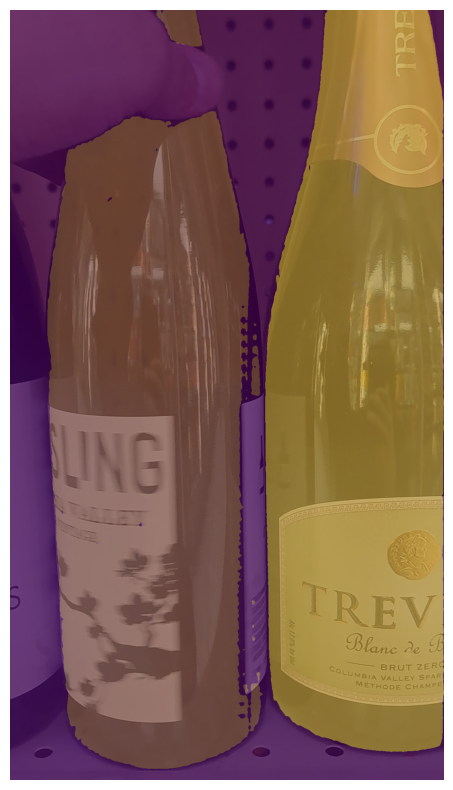

In [66]:
plt.figure(figsize=(10,10))
plt.imshow(image_np)

for mask in masks_out:
    plt.imshow(mask, alpha=0.45)

plt.axis("off")
plt.show()
